In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as const
import postgkyl as pg

In [3]:
# Calculate cell centered values from any edge values 1D array
def cell_center_values(cell_edge_values):
  center = (cell_edge_values[:-1]+cell_edge_values[1:])/2
  return center

# Get distribution function data from gkyl output file
def getDist(file, vdim):
 data = pg.GData(file)
 dg = pg.GInterpModal(data, 2, 'ms')
 dg.interpolate((0), overwrite=True)

 x = data.get_grid()[0]
 xc = cell_center_values(x)
 vx = data.get_grid()[1]
 vxc = cell_center_values(vx)
 f = data.get_values()[..., 0]
 if vdim == 2:
  vy = data.get_grid()[2]
  vyc = cell_center_values(vy)
  return x, xc, vx, vxc, vy, vyc, f
 else: #1V default
  return x, xc, vx, vxc, f

# Get M0 moments from gkyl output file
def getM0(file, vdim):
 data = pg.GData(file)
 dg = pg.GInterpModal(data, 2, 'ms')
 dg.interpolate((0), overwrite=True)

 M0 = data.get_values()[..., 0]
 return M0

# Get M1i moments from gkyl output file
def getM1i(file, vdim):
 data = pg.GData(file)
 dg = pg.GInterpModal(data, 2, 'ms')
 dg.interpolate((0, 1), overwrite=True)

 M1x = data.get_values()[..., 0]
 M1y = data.get_values()[..., 1]
 return M1x, M1y

# Get M2ij moments from gkyl output file
def getM2ij(file, vdim):
 data = pg.GData(file)
 dg = pg.GInterpModal(data, 2, 'ms')
 dg.interpolate((0, 1, 2), overwrite=True)

 M2xx = data.get_values()[..., 0]
 M2xy = data.get_values()[..., 1]
 M2yy = data.get_values()[..., 2]
 return M2xx, M2xy, M2yy

In [4]:
pi = const.pi
e = const.e; ep0 = const.epsilon_0
me = const.m_e; mp = const.m_p

mi = 2.014*mp
qi = e
qe = -e

TePar = 300*e
TiPar = 200*e
alpha = 1.3

n0 = 7e19

TePerp = alpha*TePar
TiPerp = alpha*TiPar
vtePar = np.sqrt(TePar/me)
vtiPar = np.sqrt(TiPar/mi)
vtePerp = np.sqrt(TePerp/me)
vtiPerp = np.sqrt(TiPerp/mi)

LNLe = 6.6 - (0.5*np.log(n0/1e20)) + (1.5*np.log(TePar/qi))
LNLi = 6.6 - (0.5*np.log(n0/1e20)) + (1.5*np.log(TiPar/qi))
nuE = (LNLe*qe**4*n0)/(12*pi**1.5*ep0**2*me**0.5*TePar**1.5)
nuI = (LNLi*qi**4*n0)/(12*pi**1.5*ep0**2*mi**0.5*TiPar**1.5)

Te = (TePar + (2*TePerp))/3
Ti = (TiPar + (2*TiPerp))/3
vte = np.sqrt(Te/me)
vti = np.sqrt(Ti/mi)
uePar = 0.5*np.sqrt(me/mi)*vte
uiPar = 50*(me/mi)*vti

wpe = np.sqrt(n0*qe**2/(ep0*me))
tEnd = 200/nuI

In [5]:
t = np.linspace(1.0e-3/nuI, 1.0e2/nuI, 6001)

# LBO

In [6]:
eX, eXC, eVX, eVCX, eVY, eVCY, fe = getDist('./lboBimax/rt_vlasov_lbo_crossBimaxwellian_1x2v_p2-elc_0.gkyl', 2)
iX, iXC, iVX, iVCX, iVY, iVCY, fi = getDist('./lboBimax/rt_vlasov_lbo_crossBimaxwellian_1x2v_p2-ion_0.gkyl', 2)

eTxx = np.zeros_like(t)
eTyy = np.zeros_like(t)
iTxx = np.zeros_like(t)
iTyy = np.zeros_like(t)

for frame in range(0, 6001, 1):
    eM0 = getM0('./lboBimax/rt_vlasov_lbo_crossBimaxwellian_1x2v_p2-elc_M0_{}.gkyl'.format(frame), 2)
    eM1x, eM1y = getM1i('./lboBimax/rt_vlasov_lbo_crossBimaxwellian_1x2v_p2-elc_M1_{}.gkyl'.format(frame), 2)
    eM2xx, _, eM2yy = getM2ij('./lboBimax/rt_vlasov_lbo_crossBimaxwellian_1x2v_p2-elc_M2ij_{}.gkyl'.format(frame), 2)
    eTxx[frame] = np.average(2*me*(eM2xx/eM0 - (eM1x/eM0)**2), weights=None)
    eTyy[frame] = np.average(2*me*(eM2yy/eM0 - (eM1y/eM0)**2), weights=None)

    iM0 = getM0('./lboBimax/rt_vlasov_lbo_crossBimaxwellian_1x2v_p2-ion_M0_{}.gkyl'.format(frame), 2)
    iM1x, iM1y = getM1i('./lboBimax/rt_vlasov_lbo_crossBimaxwellian_1x2v_p2-ion_M1_{}.gkyl'.format(frame), 2)
    iM2xx, _, iM2yy = getM2ij('./lboBimax/rt_vlasov_lbo_crossBimaxwellian_1x2v_p2-ion_M2ij_{}.gkyl'.format(frame), 2)
    iTxx[frame] = np.average(2*mi*(iM2xx/iM0 - (iM1x/iM0)**2), weights=None)
    iTyy[frame] = np.average(2*mi*(iM2yy/iM0 - (iM1y/iM0)**2), weights=None)

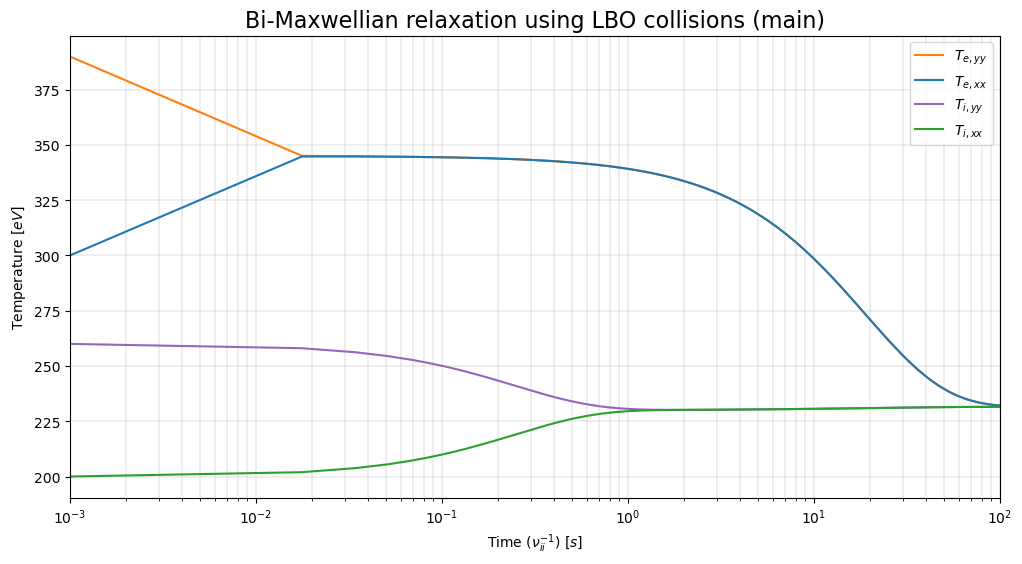

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.semilogx(t*nuI, eTyy/e, label=r'$T_{e,yy}$', color='tab:orange')
ax.semilogx(t*nuI, eTxx/e, label=r'$T_{e,xx}$', color='tab:blue')
ax.semilogx(t*nuI, iTyy/e, label=r'$T_{i,yy}$', color='tab:purple')
ax.semilogx(t*nuI, iTxx/e, label=r'$T_{i,xx}$', color='tab:green')
ax.set_title('Bi-Maxwellian relaxation using LBO collisions (main)', fontsize=16)
ax.set_xlabel(r'Time $(\nu^{-1}_{ii})$ $[s]$')
ax.set_ylabel(r'Temperature $[eV]$')
ax.set_xlim(1e-3, 1e2)
ax.grid(which='both', linewidth=0.3)
ax.legend()
plt.show()

# BGK

In [8]:
eX, eXC, eVX, eVCX, eVY, eVCY, fe = getDist('./bgkBimax/vlasov_bgk_crossBimax_1x2v_p2-elc_0.gkyl', 2)
iX, iXC, iVX, iVCX, iVY, iVCY, fi = getDist('./bgkBimax/vlasov_bgk_crossBimax_1x2v_p2-ion_0.gkyl', 2)

eTxx = np.zeros_like(t)
eTyy = np.zeros_like(t)
iTxx = np.zeros_like(t)
iTyy = np.zeros_like(t)

for frame in range(0, 6001, 1):
    eM0 = getM0('./bgkBimax/vlasov_bgk_crossBimax_1x2v_p2-elc_M0_{}.gkyl'.format(frame), 2)
    eM1x, eM1y = getM1i('./bgkBimax/vlasov_bgk_crossBimax_1x2v_p2-elc_M1_{}.gkyl'.format(frame), 2)
    eM2xx, _, eM2yy = getM2ij('./bgkBimax/vlasov_bgk_crossBimax_1x2v_p2-elc_M2ij_{}.gkyl'.format(frame), 2)
    eTxx[frame] = np.average(2*me*(eM2xx/eM0 - (eM1x/eM0)**2), weights=None)
    eTyy[frame] = np.average(2*me*(eM2yy/eM0 - (eM1y/eM0)**2), weights=None)

    iM0 = getM0('./bgkBimax/vlasov_bgk_crossBimax_1x2v_p2-ion_M0_{}.gkyl'.format(frame), 2)
    iM1x, iM1y = getM1i('./bgkBimax/vlasov_bgk_crossBimax_1x2v_p2-ion_M1_{}.gkyl'.format(frame), 2)
    iM2xx, _, iM2yy = getM2ij('./bgkBimax/vlasov_bgk_crossBimax_1x2v_p2-ion_M2ij_{}.gkyl'.format(frame), 2)
    iTxx[frame] = np.average(2*mi*(iM2xx/iM0 - (iM1x/iM0)**2), weights=None)
    iTyy[frame] = np.average(2*mi*(iM2yy/iM0 - (iM1y/iM0)**2), weights=None)

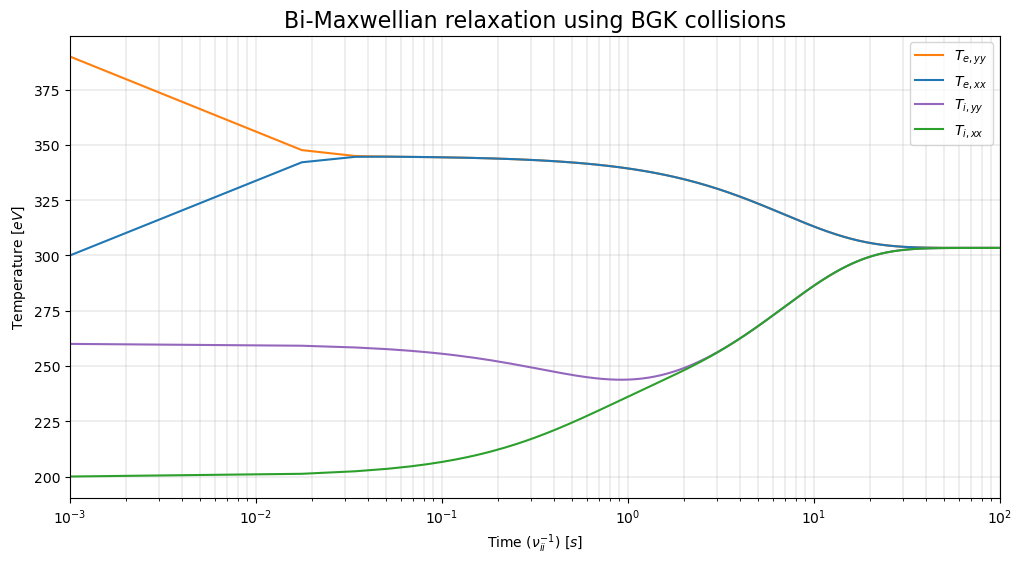

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.semilogx(t*nuI, eTyy/e, label=r'$T_{e,yy}$', color='tab:orange')
ax.semilogx(t*nuI, eTxx/e, label=r'$T_{e,xx}$', color='tab:blue')
ax.semilogx(t*nuI, iTyy/e, label=r'$T_{i,yy}$', color='tab:purple')
ax.semilogx(t*nuI, iTxx/e, label=r'$T_{i,xx}$', color='tab:green')
ax.set_title('Bi-Maxwellian relaxation using BGK collisions', fontsize=16)
ax.set_xlabel(r'Time $(\nu^{-1}_{ii})$ $[s]$')
ax.set_ylabel(r'Temperature $[eV]$')
ax.set_xlim(1e-3, 1e2)
ax.grid(which='both', linewidth=0.3)
ax.legend()
plt.show()